In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import make_scorer, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
# =========================================
# Load & preprocess data (same as before)
# =========================================

#df = pd.read_excel("input/Abbott_spreadsheet_24092025COR_BIONFO240925.xlsx")
#base_Abbott_oct

df = pd.read_excel("input/DB_Abbott_OCT2025.xlsx")#

df1 = df[["Pathogen Discovery","Pathogens confirmed (acute case)","Sex","Age","Year","Month","Site","Ocupation","Temperature",
    "Shaking chills","Headache","discomfort","irritability","confusion","fatigue","appetite loss",
    "chest pain","back pain","Abdominal pain","Bone-ache","Muscle pain","Retro orbital pain",
    "Weakness","sore throat","Cough","Diarrhea","nausea","Vomit","Rhinorrhea","Red eyes",
    "Skin rash","Jaundice","Echymosis /Hemorrhages","Respiratory distress","Dizziness",
    "Petechiae","Anosmia or ageusia","hospitalized","transfusion","SMOKER"]].copy()

df1.loc[:, "Pathogen Present"] = df1["Pathogen Discovery"].apply(lambda x: 0 if x == "NO" else 1)
df1.loc[:, "Pathogen Present"] = df1["Pathogen Present"].where(df1["Pathogens confirmed (acute case)"] == "UNDETERMINED", 1)

df1 = df1.drop(columns=["discomfort","irritability","confusion","fatigue","appetite loss",
                        "chest pain","back pain","nausea","Vomit","Jaundice","Dizziness",
                        "Petechiae","Anosmia or ageusia","transfusion","SMOKER"])

df1['Temperature'] = (
    df1['Temperature']
    .astype(str)
    .str.strip()
    .str.replace(r'[^\d\.\-]', '', regex=True)
)
df1['Temperature'] = pd.to_numeric(df1['Temperature'], errors='coerce')
df1['Temperature'] = df1['Temperature'].fillna(df1['Temperature'].median())

for col in ['Shaking chills','Headache','Abdominal pain','Bone-ache','Muscle pain',
            'Weakness']:
    df1.loc[:, col] = df1[col].where(df1[col].eq('YES'), 'NO')

for col in ['sore throat','Retro orbital pain','Cough','Diarrhea',
            'Rhinorrhea','Red eyes','Skin rash','Echymosis /Hemorrhages',
            'Respiratory distress','hospitalized']:
    df1.loc[:, col] = df1[col].where(df1[col].eq('YES'), 'NO')

X = df1.drop(columns=["Pathogen Discovery", "Pathogens confirmed (acute case)", "Pathogen Present"])
y = df1["Pathogen Present"]

categorical_features = ["Sex", "Month", 'sore throat', 'Retro orbital pain', 'Cough',
                        'Diarrhea','Shaking chills','Headache','Abdominal pain','Bone-ache',
                        'Muscle pain','Weakness','Rhinorrhea','Red eyes','Skin rash',
                        'Echymosis /Hemorrhages','Respiratory distress','hospitalized',
                        "Site","Ocupation"]
numerical_features = ['Age', 'Year', 'Temperature']

categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
numerical_transformer = MinMaxScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("encoder", categorical_transformer, categorical_features),
        ("scaler", numerical_transformer, numerical_features)
    ]
)

In [3]:
# ======================================
# Model definitions with balancing
# ======================================

neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = neg / pos

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        random_state=42, eval_metric='logloss', use_label_encoder=False,
        n_estimators=200, learning_rate=0.1, max_depth=5,
        scale_pos_weight=scale_pos_weight
    ),
    "SVM (RBF Kernel)": SVC(kernel="rbf", probability=True, random_state=42, class_weight="balanced"),
    # Models without class_weight → we’ll apply SMOTE instead
    "Neural Net (MLP)": MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB()
}

In [4]:
# ======================================
# Cross-validation setup
# ======================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score)
}

In [5]:
# ======================================
# Evaluate all models
# ======================================
results = []
best_model = None
best_f1 = -1

for name, model in models.items():
    if name in ["Neural Net (MLP)", "Naive Bayes"]:
        # SMOTE-based pipeline for models without class_weight
        pipe = ImbPipeline([
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("feature_selection", SelectKBest(score_func=f_classif, k=30)),
            ("classifier", model)
        ])
    else:
        # Regular pipeline
        pipe = ImbPipeline([
            ("preprocessor", preprocessor),
            ("feature_selection", SelectKBest(score_func=f_classif, k=30)),
            ("classifier", model)
        ])
    
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    mean_f1 = np.mean(scores["test_f1"])
    
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_model = pipe
    
    results.append({
        "Model": name,
        "Accuracy (mean)": np.mean(scores["test_accuracy"]),
        "Balanced Acc (mean)": np.mean(scores["test_balanced_accuracy"]),
        "Precision (mean)": np.mean(scores["test_precision"]),
        "Recall (mean)": np.mean(scores["test_recall"]),
        "F1 (mean)": mean_f1,
        "F1 (std)": np.std(scores["test_f1"])
    })

/Users/jandres8181/Documents/Programming-OH/select-metagenomic-samples/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:35:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jandres8181/Documents/Programming-OH/select-metagenomic-samples/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:35:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jandres8181/Documents/Programming-OH/select-metagenomic-samples/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:35:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jandres8181/Documents/Programming-OH/select-meta

In [6]:
# ======================================
# Results summary
# ======================================
results_df = pd.DataFrame(results).sort_values(by="F1 (mean)", ascending=False)

print("\n📊 Cross-Validation with Balancing:\n")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
print(f"\n🏆 Best balanced model: {best_model_name} (F1 mean = {best_f1:.3f})")

final_model = best_model.fit(X, y)
joblib.dump(final_model, f"best_model_balanced_{best_model_name.replace(' ', '_')}.pkl")
print(f"💾 Saved as best_model_balanced_{best_model_name.replace(' ', '_')}.pkl")


📊 Cross-Validation with Balancing:

              Model  Accuracy (mean)  Balanced Acc (mean)  Precision (mean)  Recall (mean)  F1 (mean)  F1 (std)
   SVM (RBF Kernel)         0.665908             0.681911          0.439585       0.718009   0.545069  0.014524
Logistic Regression         0.675688             0.680772          0.446889       0.692240   0.543108  0.016071
            XGBoost         0.675117             0.679927          0.446494       0.690776   0.542258  0.013317
        Naive Bayes         0.618715             0.642917          0.395553       0.697511   0.504714  0.014369
   Neural Net (MLP)         0.667537             0.641845          0.429812       0.583895   0.493464  0.021510
      Random Forest         0.686202             0.602253          0.433668       0.412884   0.422726  0.012270

🏆 Best balanced model: SVM (RBF Kernel) (F1 mean = 0.545)
💾 Saved as best_model_balanced_SVM_(RBF_Kernel).pkl


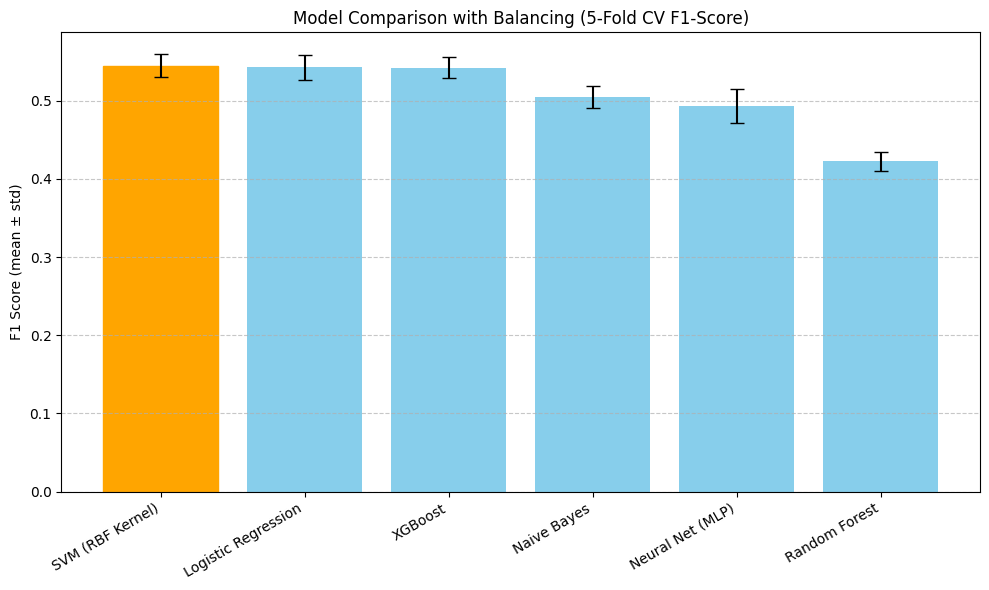

In [7]:
# ======================================
# Plot results
# ======================================
plt.figure(figsize=(10,6))
bars = plt.bar(results_df["Model"], results_df["F1 (mean)"], yerr=results_df["F1 (std)"], capsize=5, color="skyblue")
plt.title("Model Comparison with Balancing (5-Fold CV F1-Score)")
plt.ylabel("F1 Score (mean ± std)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

best_idx = results_df["Model"].tolist().index(best_model_name)
bars[best_idx].set_color("orange")

plt.tight_layout()
plt.show()

### **Nuevo identifica base nueva?** ###

In [8]:
import pandas as pd
import numpy as np
import joblib

# ======================================
# 1️⃣ Load new dataset
# ======================================
#new_df = pd.read_excel("input/Abbott_spreadsheet_con_mNGS.xlsx")
new_df = pd.read_excel("input/Abbott_spreadsheet_24092025COR_BIONFO240925.xlsx")

# Keep the ID column separately
ids = new_df["ID"]

# Select same predictor columns used during training
X_new = new_df[["Sex","Age","Year","Month","Site","Ocupation","Temperature",
    "Shaking chills","Headache","Abdominal pain","Bone-ache","Muscle pain","Weakness",
    "sore throat","Retro orbital pain","Cough","Diarrhea","Rhinorrhea","Red eyes",
    "Skin rash","Echymosis /Hemorrhages","Respiratory distress","hospitalized"]].copy()

In [9]:
# ======================================
# 2️⃣ Clean and preprocess (same as training)
# ======================================

# Fix Temperature
X_new['Temperature'] = (
    X_new['Temperature']
    .astype(str)
    .str.strip()
    .str.replace(r'[^\d\.\-]', '', regex=True)
)
X_new['Temperature'] = pd.to_numeric(X_new['Temperature'], errors='coerce')
X_new['Temperature'] = X_new['Temperature'].fillna(X_new['Temperature'].median())

# Normalize YES/NO symptoms
for col in ['Shaking chills','Headache','Abdominal pain','Bone-ache','Muscle pain',
            'Weakness','sore throat','Retro orbital pain','Cough','Diarrhea',
            'Rhinorrhea','Red eyes','Skin rash','Echymosis /Hemorrhages',
            'Respiratory distress','hospitalized']:
    X_new.loc[:, col] = X_new[col].where(X_new[col].eq('YES'), 'NO')

In [10]:
# ======================================
# 3️⃣ Load the trained model
# ======================================
# ⚠️ Change this filename if your model had a different name
model = joblib.load("best_model_balanced_SVM_(RBF_Kernel).pkl")

# ======================================
# 4️⃣ Generate predictions
# ======================================
predictions = model.predict(X_new)

# Some models (like SVM) have probability=True, so this works:
if hasattr(model, "predict_proba"):
    probabilities = model.predict_proba(X_new)[:, 1]
else:
    # fallback: use decision_function if probabilities not available
    try:
        scores = model.decision_function(X_new)
        probabilities = (scores - scores.min()) / (scores.max() - scores.min())
    except:
        probabilities = np.zeros_like(predictions)

In [11]:
# ======================================
# 5️⃣ Build the result table
# ======================================
results = pd.DataFrame({
    "ID": ids,
    "Predicted_Pathogen_Present": predictions,
    "Predicted_Probability": probabilities
})

# Combine with some useful context columns (optional)
results = results.merge(
    new_df[["ID","Temperature","Cough","Headache","Site","Month"]],
    on="ID",
    how="left"
)

In [12]:
# ======================================
# 6️⃣ Sort by probability and save
# ======================================
results = results.sort_values(by="Predicted_Probability", ascending=False)
results.to_excel("predicted_pathogen_candidates_with_ID.xlsx", index=False)

print("✅ Prediction file saved as 'predicted_pathogen_candidates_with_ID.xlsx'")
display(results.head())

✅ Prediction file saved as 'predicted_pathogen_candidates_with_ID.xlsx'


,ID,Predicted_Pathogen_Present,Predicted_Probability,Temperature,Cough,Headache,Site,Month
2326,0400454,1,0.668072,38.0,NO,YES,APARTADÓ,MAR
2353,0400481,1,0.665787,39.2,NO,YES,APARTADÓ,MAR
11478,0304370,1,0.655780,40.1,NO,YES,VILLAVICENCIO,MAR
3904,LET-06H,1,0.648294,NaN,NR,NR,LETICIA,JAN
9759,0302649,1,0.636800,36.2,NO,YES,VILLAVICENCIO,MAR


In [13]:
import pandas as pd
import numpy as np
import joblib

# ======================================
# 1️⃣ Load new dataset
# ======================================
new_df = pd.read_excel("input/Abbott_spreadsheet_con_mNGS.xlsx")

# Keep ID and reference columns
ids = new_df["ID"]
pathogens_confirmed = new_df["Pathogens confirmed (acute case)"]
metagenomics_seq = new_df["Metagenomics Seq"]

# Select only predictor columns (same as model training)
X_new = new_df[["Sex","Age","Year","Month","Site","Ocupation","Temperature",
    "Shaking chills","Headache","Abdominal pain","Bone-ache","Muscle pain","Weakness",
    "sore throat","Retro orbital pain","Cough","Diarrhea","Rhinorrhea","Red eyes",
    "Skin rash","Echymosis /Hemorrhages","Respiratory distress","hospitalized"]].copy()

# ======================================
# 2️⃣ Clean and preprocess (same as training)
# ======================================

# Clean Temperature
X_new['Temperature'] = (
    X_new['Temperature']
    .astype(str)
    .str.strip()
    .str.replace(r'[^\d\.\-]', '', regex=True)
)
X_new['Temperature'] = pd.to_numeric(X_new['Temperature'], errors='coerce')
X_new['Temperature'] = X_new['Temperature'].fillna(X_new['Temperature'].median())

for col in ['Shaking chills','Headache','Abdominal pain','Bone-ache','Muscle pain',
            'Weakness']:
    df1.loc[:, col] = df1[col].where(df1[col].eq('YES'), 'NO')

for col in ['sore throat','Retro orbital pain','Cough','Diarrhea',
            'Rhinorrhea','Red eyes','Skin rash','Echymosis /Hemorrhages',
            'Respiratory distress','hospitalized']:
    df1.loc[:, col] = df1[col].where(df1[col].eq('YES'), 'NO')

# ======================================
# 3️⃣ Load trained model
# ======================================
# ⚠️ Update the filename if needed
model = joblib.load("best_model_balanced_SVM_(RBF_Kernel).pkl")

# ======================================
# 4️⃣ Generate predictions
# ======================================
predictions = model.predict(X_new)

# Probability (or fallback decision function)
if hasattr(model, "predict_proba"):
    probabilities = model.predict_proba(X_new)[:, 1]
else:
    try:
        scores = model.decision_function(X_new)
        probabilities = (scores - scores.min()) / (scores.max() - scores.min())
    except:
        probabilities = np.zeros_like(predictions)

# ======================================
# 5️⃣ Build the final results dataframe
# ======================================
results = pd.DataFrame({
    "ID": ids,
    "Pathogens confirmed (acute case)": pathogens_confirmed,
    "Metagenomics Seq": metagenomics_seq,
    "Predicted_Pathogen_Present": predictions,
    "Predicted_Probability": probabilities
})

# Add a few optional context variables for quick review
results = results.merge(
    new_df[["ID","Temperature","Cough","Headache","Site","Month"]],
    on="ID",
    how="left"
)

# ======================================
# 6️⃣ Sort by probability and save
# ======================================
results = results.sort_values(by="Predicted_Probability", ascending=False)
results.to_excel("predicted_pathogen_candidates_with_ID_confirmed_seq_2.xlsx", index=False)

print("✅ Prediction file saved as 'predicted_pathogen_candidates_with_ID_confirmed_seq.xlsx'")
display(results.head(10))


✅ Prediction file saved as 'predicted_pathogen_candidates_with_ID_confirmed_seq.xlsx'


,ID,Pathogens confirmed (acute case),Metagenomics Seq,Predicted_Pathogen_Present,Predicted_Probability,Temperature,Cough,Headache,Site,Month
21,LET-1430,MYV,MAYARO VIRUS,1,0.509217,39.0,NO,YES,LETICIA,APR
14,0400677,UNDETERMINED,PEGIVIRUS C,1,0.500000,39.0,NO,YES,APARTADÓ,JUL
8,0400006,UNDETERMINED,PEGIVIRUS A,1,0.500000,39.0,NO,YES,APARTADÓ,JUN
69,0302872,DENV,NT,1,0.500000,36.8,NO,YES,VILLAVICENCIO,JUN
11,0400297,COV,SARS-CoV-2,1,0.500000,39.0,YES,NO,APARTADÓ,DEC
10,0400205,UNDETERMINED,PEGIVIRUS C,1,0.493221,38.5,NO,YES,APARTADÓ,OCT
24,LET-1735,UNDETERMINED,MANSONELLA,1,0.492582,38.2,NO,YES,LETICIA,AUG
61,LET-1309,DENV,NT,1,0.492289,37.5,NO,YES,LETICIA,FEB
63,LET-1314,DENV,NT,1,0.489871,37.8,NO,YES,LETICIA,FEB
13,0400549,UNDETERMINED,PEGIVIRUS C,1,0.486352,38.4,NO,YES,APARTADÓ,MAY


In [14]:
import pandas as pd
import numpy as np
import joblib

# ======================================
# 1️⃣ Load new dataset
# ======================================
new_df = pd.read_excel("input/seleccion-nuevas-muestras-nov-dic2025.xlsx")

# Keep ID and reference columns
ids = new_df["ID"]
pathogens_confirmed = new_df["Pathogens confirmed (acute case)"]
metagenomics_seq = new_df["Metagenomics Seq"]

# Select predictor columns (same as model training)
X_new = new_df[["Sex","Age","Year","Month","Site","Ocupation","Temperature",
    "Shaking chills","Headache","Abdominal pain","Bone-ache","Muscle pain","Weakness",
    "sore throat","Retro orbital pain","Cough","Diarrhea","Rhinorrhea","Red eyes",
    "Skin rash","Echymosis /Hemorrhages","Respiratory distress","hospitalized"]].copy()

# ======================================
# 2️⃣ Clean and preprocess (same as training)
# ======================================

# Fix Temperature
X_new['Temperature'] = (
    X_new['Temperature']
    .astype(str)
    .str.strip()
    .str.replace(r'[^\d\.\-]', '', regex=True)
)
X_new['Temperature'] = pd.to_numeric(X_new['Temperature'], errors='coerce')

# Convert Age and Year to numeric too (safety)
for num_col in ['Age', 'Year']:
    X_new[num_col] = pd.to_numeric(X_new[num_col], errors='coerce')

# Fill missing numeric values with medians
for num_col in ['Age', 'Year', 'Temperature']:
    X_new[num_col] = X_new[num_col].fillna(X_new[num_col].median())

# Normalize YES/NO symptom variables
for col in ['Shaking chills','Headache','Abdominal pain','Bone-ache','Muscle pain',
            'Weakness']:
    X_new.loc[:, col] = X_new[col].where(X_new[col].eq('YES'), 'NO')

for col in ['sore throat','Retro orbital pain','Cough','Diarrhea',
            'Rhinorrhea','Red eyes','Skin rash','Echymosis /Hemorrhages',
            'Respiratory distress','hospitalized']:
    X_new.loc[:, col] = X_new[col].where(X_new[col].eq('YES'), 'NO')



# ======================================
# 3️⃣ Extra type safety checks before prediction
# ======================================
print("🔍 Checking data types before prediction:")
print(X_new.dtypes)

# Strip whitespace from string columns
for col in X_new.columns:
    if X_new[col].dtype == object:
        X_new[col] = X_new[col].astype(str).str.strip()

# Coerce any leftover numeric columns again
for num_col in ['Age', 'Year', 'Temperature']:
    X_new[num_col] = pd.to_numeric(X_new[num_col], errors='coerce')
    X_new[num_col] = X_new[num_col].fillna(X_new[num_col].median())

print("\n✅ Number of missing values before prediction:")
print(X_new.isna().sum())

# ======================================
# 4️⃣ Load the trained model
# ======================================
# ⚠️ Change this filename if your model had a different name
model = joblib.load("best_model_balanced_SVM_(RBF_Kernel).pkl")

# ======================================
# 5️⃣ Generate predictions
# ======================================
predictions = model.predict(X_new)

# Compute probabilities (or fallback to decision_function)
if hasattr(model, "predict_proba"):
    probabilities = model.predict_proba(X_new)[:, 1]
else:
    try:
        scores = model.decision_function(X_new)
        probabilities = (scores - scores.min()) / (scores.max() - scores.min())
    except Exception as e:
        print("⚠️ No probability or decision function available:", e)
        probabilities = np.zeros_like(predictions)

# ======================================
# 6️⃣ Build the final results DataFrame
# ======================================
results = pd.DataFrame({
    "ID": ids,
    "Pathogens confirmed (acute case)": pathogens_confirmed,
    "Metagenomics Seq": metagenomics_seq,
    "Predicted_Pathogen_Present": predictions,
    "Predicted_Probability": probabilities
})

# Add some useful context columns (optional)
context_cols = ["Temperature", "Cough", "Headache", "Site", "Month"]
context_cols = [c for c in context_cols if c in new_df.columns]  # avoid errors if missing

results = results.merge(
    new_df[["ID"] + context_cols],
    on="ID",
    how="left"
)

# ======================================
# 7️⃣ Sort by probability and save
# ======================================
results = results.sort_values(by="Predicted_Probability", ascending=False)
results.to_excel("predicted_pathogen_nov-dic.xlsx", index=False)

print("\n✅ Prediction file saved as 'predicted_pathogen_nov-dic.xlsx'")
display(results.head(10))


🔍 Checking data types before prediction:
Sex                        object
Age                       float64
Year                        int64
Month                      object
Site                       object
Ocupation                  object
Temperature               float64
Shaking chills             object
Headache                   object
Abdominal pain             object
Bone-ache                  object
Muscle pain                object
Weakness                   object
sore throat                object
Retro orbital pain         object
Cough                      object
Diarrhea                   object
Rhinorrhea                 object
Red eyes                   object
Skin rash                  object
Echymosis /Hemorrhages     object
Respiratory distress       object
hospitalized               object
dtype: object

✅ Number of missing values before prediction:
Sex                       0
Age                       0
Year                      0
Month                     0
Site

,ID,Pathogens confirmed (acute case),Metagenomics Seq,Predicted_Pathogen_Present,Predicted_Probability,Temperature,Cough,Headache,Site,Month
130,LET-3340,MALA,NT,1,0.546233,37.0,NO,YES,LETICIA,NOV
97,LET-3307,UNDETERMINED,NT,1,0.546129,37.0,NO,YES,LETICIA,NOV
44,0402080,UNDETERMINED,NT,1,0.543138,36.9,NO,YES,APARTADÓ,NOV
114,LET-3324,UNDETERMINED,NT,1,0.537970,38.0,NO,YES,LETICIA,NOV
84,0402120,MALA,NT,1,0.537145,37.5,NO,YES,APARTADÓ,DIC
94,LET-3304,MALA,NT,1,0.533073,38.2,NO,YES,LETICIA,NOV
90,0402126,UNDETERMINED,NT,1,0.519500,36.5,YES,YES,APARTADÓ,DIC
83,0402119,UNDETERMINED,NT,1,0.518910,37.3,NO,YES,APARTADÓ,DIC
67,0402103,DENV,NT,1,0.518745,36.5,NO,YES,APARTADÓ,NOV
51,0402087,UNDETERMINED,NT,1,0.516429,38.0,NO,YES,APARTADÓ,NOV
